In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import scipy.signal
from datetime import datetime
import matplotlib.dates as mdates

In [15]:
folder_path = Path("C:/Users/ezra/OneDrive - Delft University of Technology/School/Universiteit/BEP/Raw Data")

# Create a dictionary mapping filename -> full path
file_dict = {
    f.name: str(f.resolve()) for f in folder_path.iterdir() if f.is_file()
}
key_list = list(file_dict.keys())
print(file_dict.keys())

dict_keys(['2026-06-19 - TN binnen 2.txt', '2026-06-19 - TN binnen.txt', '2026-06-22 - TN binnen.txt', '2026-06-23 12.25 - GV.txt', '2026-06-24 16.52 - GV.txt', '2026-06-29 09.45 - GV 14.45End.txt', '2026-06-30 00.10 - GV - 2e diode stuk.txt', '2026-07-02 14.51 - GV.txt', 'log_000.txt', 'log_001.txt', 'log_004.txt', 'log_20260709_1236.txt', 'log_20260709_1632_0.txt', 'log_20260713_1253.txt', 'log_20260714_0903.txt', 'log_20260714_1650_0_test.txt', 'log_20260714_1655_0_test.txt', 'log_20260714_1721_test.txt', 'log_20260714_1729_test.txt', 'log_20260714_1744_0_test.txt', 'log_20260714_1756_0_test.txt', 'log_20260714_1757_test.txt', 'log_20260714_1806_test.txt', 'log_20260715_1228_test.txt', 'log_20260715_1325_testbox.txt', 'log_20260715_1513_testbox.txt', 'log_20260715_1556_first_v5.txt'])


In [16]:
filenumber = 26
fname = Path(key_list[filenumber]).stem
print('Selected file:',fname)
data = np.loadtxt(fname = file_dict[key_list[filenumber]], usecols = (1,2,3,4,5,6,7,8), skiprows=1,delimiter=',')

# Extract the first column (DateTime) as strings. 
# Adjust 'your_file.csv' and the skiprows/delimiter as needed for your specific import method.
raw_time_strs = np.genfromtxt(fname = file_dict[key_list[filenumber]], delimiter=',', usecols=0, dtype=str, skip_header=1)

# Convert strings to datetime objects
parsed_dates = np.array([datetime.strptime(ts, "%Y-%m-%d %H:%M:%S") for ts in raw_time_strs])

Selected file: log_20260715_1556_first_v5


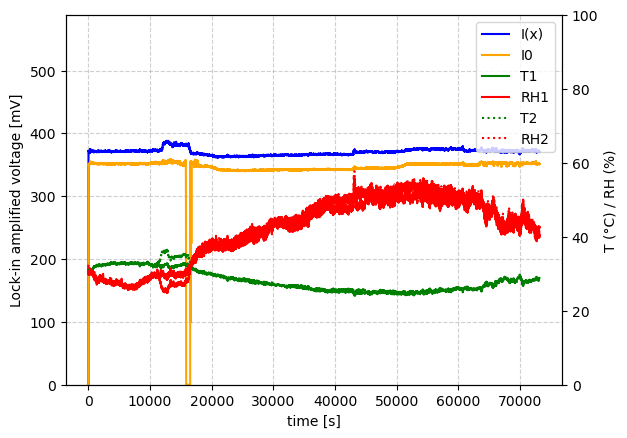

In [17]:
# Create the main plot and the first y-axis
fig, ax1 = plt.subplots()

# Plot I(x) and I0 on the left y-axis
#line7 = ax1.plot(data[:,6],',', label='I(x)DC')
#line8 = ax1.plot(data[:,7],',', label='I0DC')
line1 = ax1.plot(data[:,0], label='I(x)', color='blue')
line2 = ax1.plot(data[:,1], label='I0', color='orange')

ax1.set_ylim(0, np.max(data[:,0])+200)
ax1.set_ylabel('Lock-in amplified voltage [mV]') # Customize this label as needed

# --- ADDED GRID HERE ---
# Using a dashed line and lower alpha (opacity) keeps it from overpowering your data
ax1.grid(True, linestyle='--', alpha=0.6) 

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot T and RH on the right y-axis (removing the *30 multiplier since we have the 0-100 scale)
line3 = ax2.plot(data[:,2], label='T1', color='green')
line4 = ax2.plot(data[:,3], label='RH1', color='red')
line5 = ax2.plot(data[:,4],':g' , label='T2')
line6 = ax2.plot(data[:,5],':r' , label='RH2')



ax2.set_ylabel('T (°C) / RH (%)')
ax2.set_ylim(0, 100) # Set the range from 0 to 100

# Combine legends from both axes
lines = line1 + line2 + line3 + line4 + line5 + line6# + line7 + line8
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
ax1.set_xlabel('time [s]')

plt.show()

ADC noise after integration window =  0.08222774405094897 mV


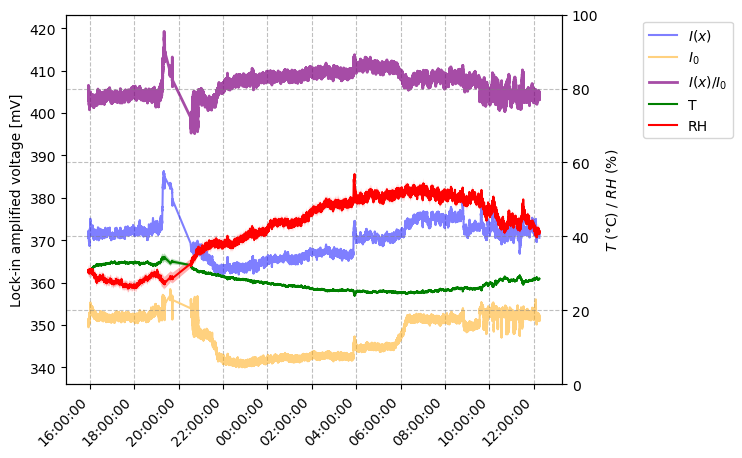

In [18]:
xmin,xmax = 10,np.size(data[:,0])-10


#xmin,xmax = 155,300 #testbox1
#xmin,xmax = 110,300 #testbox2 closed
#xmin,xmax = 350,650 #testbox2 opened
#xmin,xmax = 1000,70000
#xmin,xmax = 25000,40000 #outside1

# 1. Slice the data to your window of interest FIRST
data_window = data[xmin:xmax]
dates_window = parsed_dates[xmin:xmax] # <--- Slice the dates identically

# 2. Extract your variables from the window
Ix = data_window[:, 0]
I0 = data_window[:, 1]
T1 = data_window[:, 2]
RH1 = data_window[:, 3]
T2 = data_window[:, 4]
RH2 = data_window[:, 5]
T = np.mean(data_window[:, 2:5:2], axis=1)
RH = np.mean(data_window[:, 3:6:2], axis=1)
IxDC = data_window[:, 6]
I0DC = data_window[:, 7]

# 3. Calculate ratio safely
ratio = np.divide(Ix, I0, out=np.zeros_like(Ix), where=I0 > 0)

# Create mask: True for good data, False for data to clip
valid_mask = (np.abs(ratio - np.median(ratio)) <= 0.1) & (ratio != 0) & (I0DC <= 800) & (IxDC <= 800)

# 4. Apply the mask to ALL variables (True elements are kept, False are dropped)
Ix_clipped = Ix[valid_mask]
I0_clipped = I0[valid_mask]
ratio_clipped = ratio[valid_mask]
T_clipped = T[valid_mask]
RH_clipped = RH[valid_mask]
x_clipped = dates_window[valid_mask] # <--- Apply the mask to the dates

# Uncertainty
dTa_clipped = (np.abs(T1-T2)/np.sqrt(12))[valid_mask] 
dRHa_clipped = (np.abs(RH1-RH2)/np.sqrt(12))[valid_mask] 
dTs = 0.5/np.sqrt(3) 
dRHs = 3/np.sqrt(3) 

dT = np.sqrt(dTs**2/2 + dTa_clipped**2) 
dRH = np.sqrt(dRHs**2/2 + dRHa_clipped**2) 

Nint = 800 
dADC = 5*3300/4096/np.sqrt(3*Nint) 
print('ADC noise after integration window = ', dADC, 'mV')

# --- Plotting ---
fig, ax1 = plt.subplots()

# Left Y-Axis: Intensities and Ratio
line1 = ax1.plot(x_clipped, Ix_clipped, label='$I(x)$', color='blue', alpha=0.5)
line2 = ax1.plot(x_clipped, I0_clipped, label='$I_0$', color='orange', alpha=0.5)
line3 = ax1.plot(x_clipped, ratio_clipped * 1.1 * np.mean(I0_clipped), label='$I(x)/I_0$', color='purple', linewidth=2, alpha=0.7)
ax1.set_ylabel('Lock-in amplified voltage [mV]')
ax1.grid(True, axis='x', linestyle='--', alpha=0.5, color='gray')

# Right Y-Axis: Weather Data
ax2 = ax1.twinx()

# Plot T and its shaded uncertainty band
line4 = ax2.plot(x_clipped, T_clipped, label='T', color='green')
ax2.fill_between(x_clipped, T_clipped - dT, T_clipped + dT, color='green', alpha=0.3, edgecolor='none')

# Plot RH and its shaded uncertainty band
line5 = ax2.plot(x_clipped, RH_clipped, label='RH', color='red')
ax2.fill_between(x_clipped, RH_clipped - dRH, RH_clipped + dRH, color='red', alpha=0.3, edgecolor='none')

ax2.set_ylabel('$T$ (°C) / $RH$ (%)')
ax2.set_ylim(0, 100)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5, color='gray')

# --- Strictly Format X-Axis for TIME ONLY ---
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# Rotate labels 45 degrees so they don't overlap
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Combine legends
lines = line1 + line2 + line3 + line4 + line5
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.15, 1.0))

plt.savefig(f'{fname}raw.png', dpi=500, bbox_inches='tight')
plt.show()

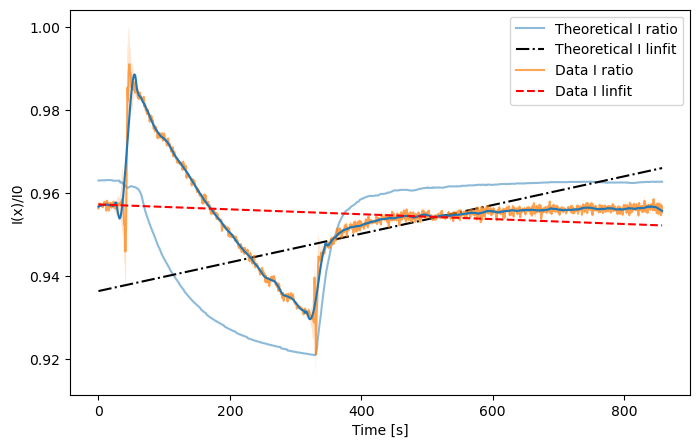

Theoretical slope: 3.4504308593724915e-05
Data slope: -5.874626007806287e-06
1.396365102128627e-06 0.0006919140557086065


In [13]:
def Molarsat(T): #saturation molarity at T[C]
    R = 8.314
    return 611.21/R/(T+273.15)*np.exp((18.678 - T/234.5 )*( T/(257.14 + T)))

def Molarsat_unc(T, delta_T):
    """
    Calculates the uncertainty of saturation molarity.
    T: Temperature in Celsius
    delta_T: Uncertainty in Temperature in Celsius (or Kelvin, the interval is the same)
    """
    h = 1e-5  # A very small step size for the derivative
    
    # Calculate the derivative: dy/dx = (f(x+h) - f(x-h)) / 2h
    derivative = (Molarsat(T + h) - Molarsat(T - h)) / (2 * h)
    
    # Propagate the error
    uncertainty = np.abs(derivative) * delta_T
    
    return uncertainty


def Absorption_coef(T,alpha_h2o,x,RH): #absorption coefficient in a natural exponential
    return Molarsat(T)*alpha_h2o*x*RH

def Ac_M(M_H2O,alpha_h2o,x): #absorption coefficient in a natural exponential
    return M_H2O*alpha_h2o*x
    
def linfit(x,a,b):
    return a*x+b


M_s = Molarsat(T_clipped)
dM_s = Molarsat_unc(T_clipped, dT)

alpha_h2o = 2.8/(101325/8.314/296) #2.8 is for pure H2O at 1 atm and 296 K, the deviding factor is equal to the molar concentration of pure H2O vapour
x = 0.97 # pathlength in m
t_arr = np.arange(0,np.size(T_clipped)) # time array

M_h2o = M_s*RH_clipped/100
dM_h2o = np.sqrt((dM_s/M_s)**2 + (dRH/RH_clipped)**2)*M_h2o

I_ratio = np.exp(-Absorption_coef(T_clipped,alpha_h2o,x,RH_clipped/100)) # theoretical I(x)/I0

# 70% RH clipping:
RH_mask = RH_clipped <= 70
ratio_clippedm = ratio_clipped[RH_mask]
M_h2om = M_h2o[RH_mask]
I_ratiom = I_ratio[RH_mask]


ratio_sc = ratio_clipped/np.mean(ratio_clippedm)*np.mean(I_ratiom)
ratio_scm = ratio_sc[RH_mask]


var_data,cov_data = curve_fit(linfit,t_arr,ratio_sc)
var_theoretical,cov_theoretical = curve_fit(linfit,t_arr,I_ratio)

# --- Combined Uncertainty Estimation (Scipy + NumPy) ---

# 1. Isolate the noise cleanly using Savitzky-Golay on ratio_sc
window_len = 31
poly_order = 3

Iy_smooth = scipy.signal.savgol_filter(ratio_sc, window_length=window_len, polyorder=poly_order, mode='nearest')
residuals = ratio_sc - Iy_smooth

# 2. Compute Rolling Uncertainty over residuals (Length matched to ratio_sc)
noise_window = 11  
dY = np.zeros_like(ratio_sc) # Fixed: base size on ratio_sc directly

half_w = noise_window // 2
n_points = len(ratio_sc)

for i in range(n_points):
    start = max(0, i - half_w)
    end = min(n_points, i + half_w + 1)
    dY[i] = np.std(residuals[start:end])

    
# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot Theoretical models
plt.plot(t_arr, I_ratio, alpha=0.5, label='Theoretical I ratio', color='tab:blue')
plt.plot(t_arr, linfit(t_arr, *var_theoretical), 'k-.', alpha=1, label='Theoretical I linfit')

# Plot Data Ratio Line
plt.plot(t_arr, ratio_sc, alpha=0.7, label='Data I ratio', color='tab:orange')
plt.plot(t_arr, Iy_smooth)

# ADD THE SHADED UNCERTAINTY BAND HERE around the Data Ratio
# Using color='tab:orange' and alpha=0.2 matching the data line style
plt.fill_between(t_arr, ratio_sc - dY, ratio_sc + dY, color='tab:orange', alpha=0.2, edgecolor='none')

# Plot Data linear fit
plt.plot(t_arr, linfit(t_arr, *var_data), 'r--', alpha=1, label='Data I linfit')


plt.xlabel('Time [s]')
plt.ylabel('I(x)/I0')
plt.legend(loc='upper right')
plt.show()

print('Theoretical slope:', var_theoretical[0])
print('Data slope:', var_data[0])
print(np.sqrt(cov_data[0,0]), np.sqrt(cov_data[1,1]))

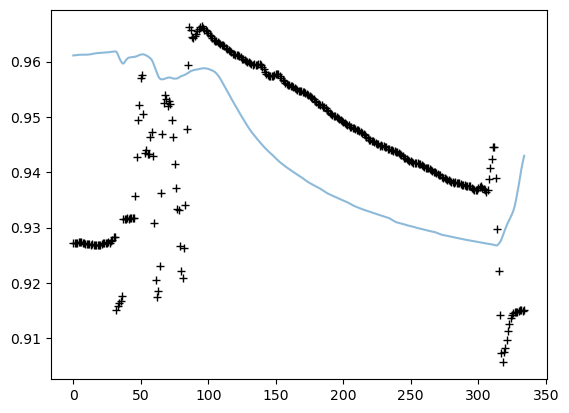

In [7]:
def rolling_average(data, n):
    """
    Computes the rolling average over n points and clips incomplete edge windows.
    """
    # Create a uniform weight window that sums to 1
    weights = np.ones(n) / n
    
    # 'valid' mode automatically removes the front and back edge artifacts
    return np.convolve(data, weights, mode='valid')

N = 5 #number of data points in rolling average

t_arr = np.arange(0,np.size(T_clipped),1)



I_ratio_ra = rolling_average(np.exp(-Absorption_coef(T_clipped,alpha_h2o,x,RH_clipped/100)),N) #rolling average
I_rollingavg = rolling_average(ratio_clipped,N) 
I_rollingavg_s = I_rollingavg/np.mean(I_rollingavg)*np.mean(I_ratio) #rolling average and scaled

plt.plot(I_ratio_ra, alpha = 0.5)
plt.plot(I_rollingavg_s, 'k+')

calculated alpha from fit: -1.158877620578877
extra I(x)/I(0) multiplicative scaling factor: 1.0744038840032741
[[ 5.21823502e-05 -4.32489145e-05]
 [-4.32489145e-05  3.74300025e-05]]
Mean molar saturation = 1.485389796302009
70.68851574274005


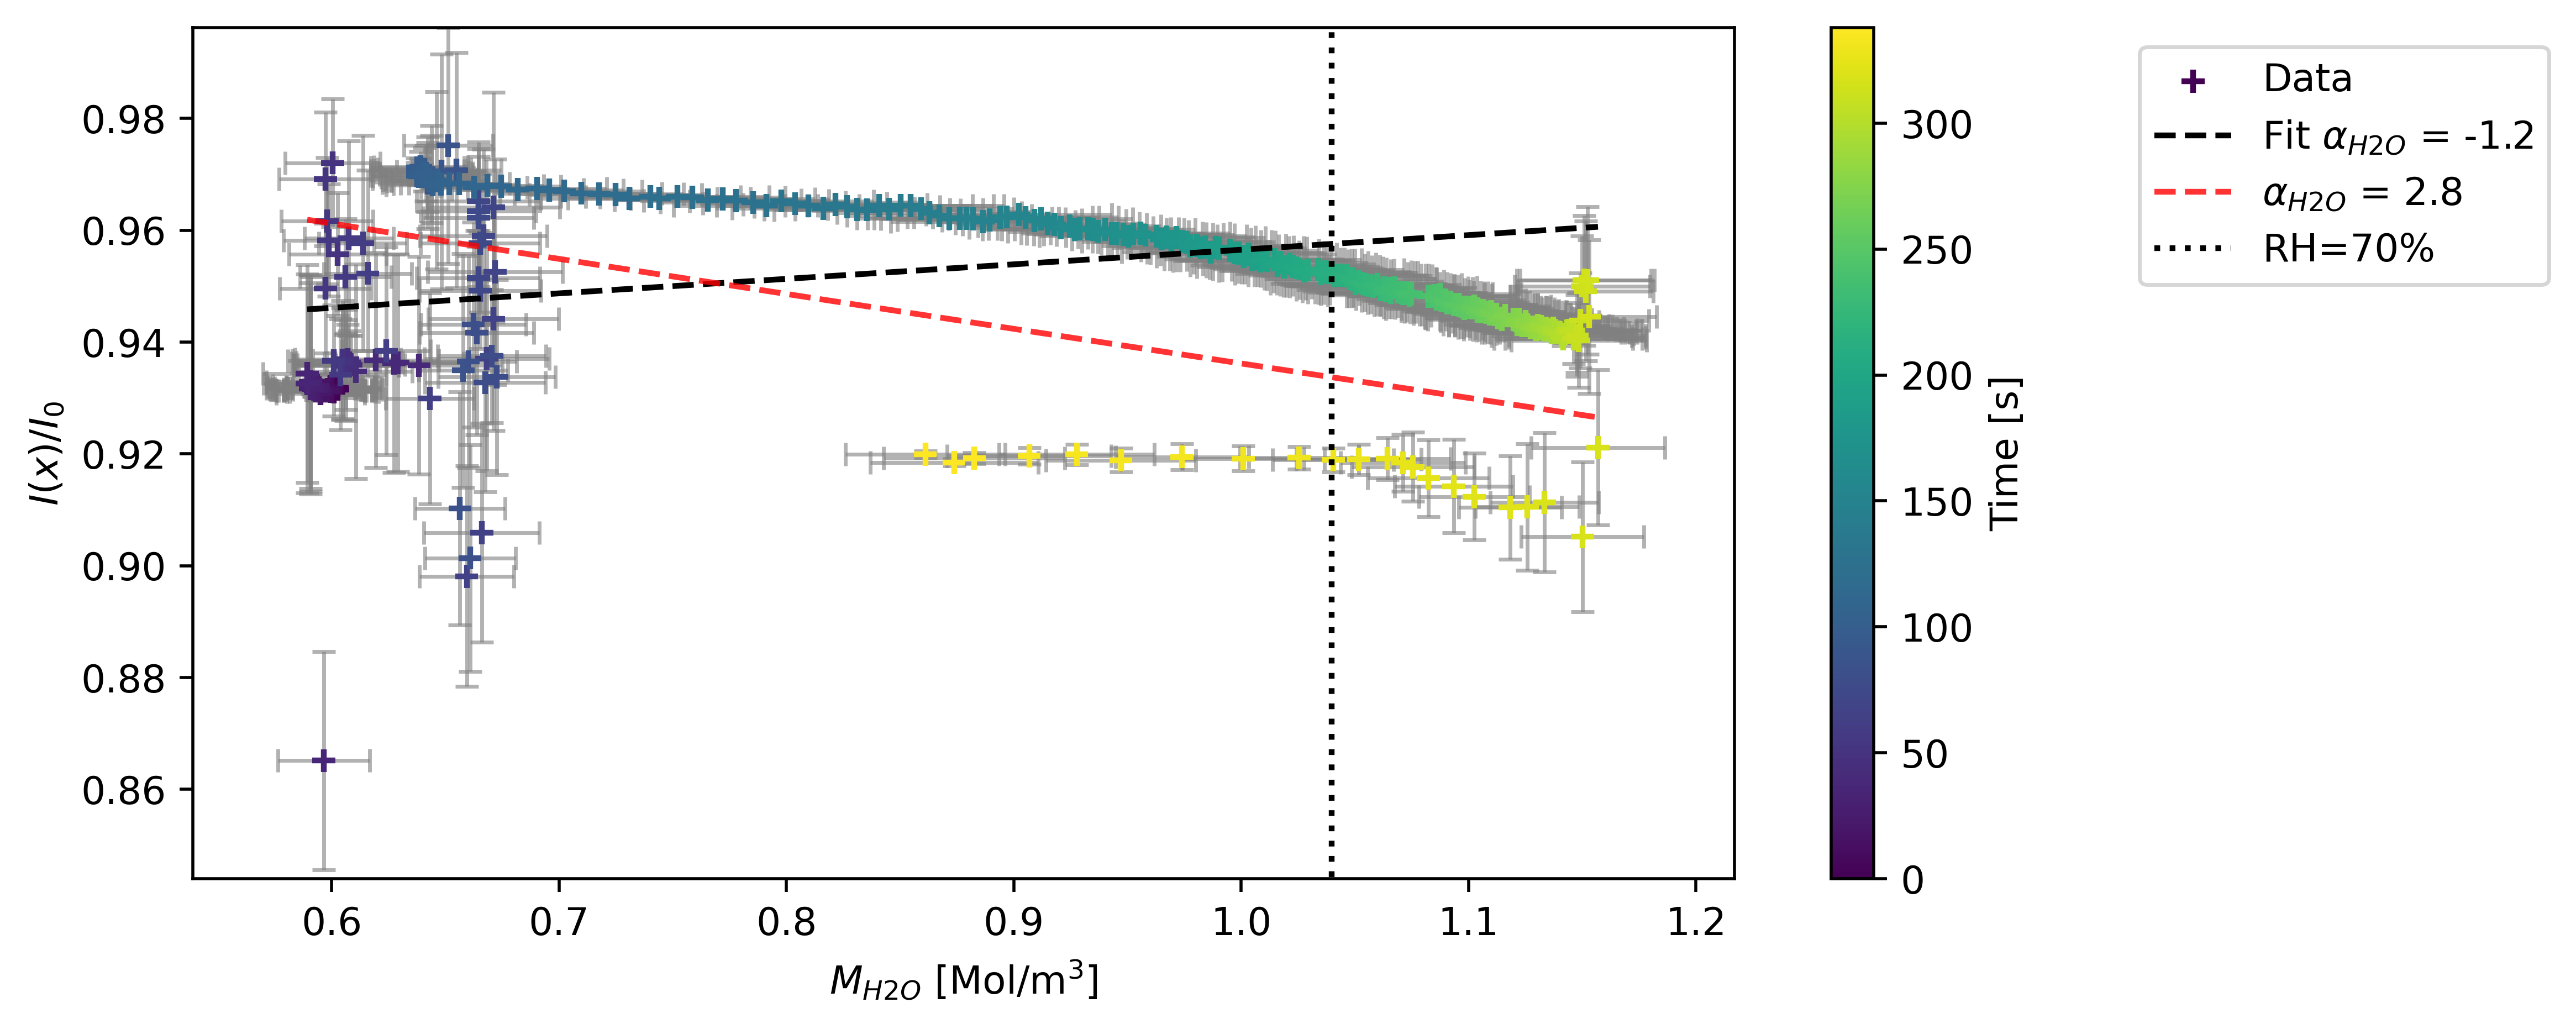

In [8]:
def fitfunc(I_sc_data,alphax,const):
    return -np.log(const*I_sc_data)/alphax
def fitfunc2(M_h2o,alphax,const):
    return np.exp(-M_h2o*alphax)/const



#var, cov = curve_fit(fitfunc, ratio_sc, M_h2o, p0=(2.5,0.99), maxfev=5000)
var2, cov2 = curve_fit(fitfunc2, M_h2om, ratio_scm, p0=(2,1), maxfev=5000)
xtest = np.linspace(np.min(M_h2o), np.max(M_h2o), num=100)
alphafit = var2[0]*(101325/8.314/296)/x
# 1. Create an array of indices corresponding to the position in the array
point_positions = np.arange(len(M_h2o))



plt.figure(dpi = 500, figsize = (9,4))
# 2. Draw the error bars FIRST
# fmt='none' prevents it from drawing data points
# ecolor sets the line color of the error bars (e.g., 'gray', 'black', 'lightgray')
# zorder=1 puts the error bars in the background
plt.errorbar(M_h2o, ratio_sc, xerr=dM_h2o, yerr=dY, fmt='none', ecolor='gray', 
             elinewidth=1, capsize=3, alpha=0.6, zorder=1)

# 3. Draw your colored scatter points ON TOP
# zorder=2 ensures the colored points sit on top of the error bars
plt.scatter(M_h2o, ratio_sc, c=point_positions, cmap='viridis', marker='+', 
            label='Data', zorder=2)


# 3. Add a colorbar to show the index gradient scale
plt.colorbar(label='Time [s]')


#plt.plot(fitfunc(ratio_sc, 0.0615,1), ratio_sc, label = 'data')
plt.plot(xtest, fitfunc2(xtest, *var2),'k--' , label = r'Fit $\alpha_{H2O}$ = '+str(np.round(alphafit,1)))
#plt.plot(M_h2o,I_ratio,'r--' , label = r'$\alpha_{H2O}$ = 2.8', alpha = 0.8)
plt.plot(xtest,np.exp(-Ac_M(xtest,alpha_h2o,x)),'r--' , label = r'$\alpha_{H2O}$ = 2.8', alpha = 0.8)
plt.vlines(0.7*Molarsat(np.mean(T)),0,1,'k', linestyle=':' , label = 'RH=70%')

plt.xlabel('$M_{H2O}$ [Mol/m$^3$]')
plt.ylabel('$I(x)/I_0$')
plt.ylim(np.min(ratio_sc)-np.max(dY), np.max(ratio_sc)+np.max(dY))

# Place legend outside to the right, pushing past the colorbar (x=1.25)
plt.legend(loc='upper left', bbox_to_anchor=(1.25, 1.0))

# Add bbox_inches='tight' so the saved image expands to fit the legend
plt.savefig(f'{fname}.png', dpi=500, bbox_inches='tight')


print('calculated alpha from fit:',alphafit)
print('extra I(x)/I(0) multiplicative scaling factor:',var2[1])
print(cov2)
print('Mean molar saturation =',Molarsat(np.mean(T)))
print(100*1.05/Molarsat(np.mean(T)))


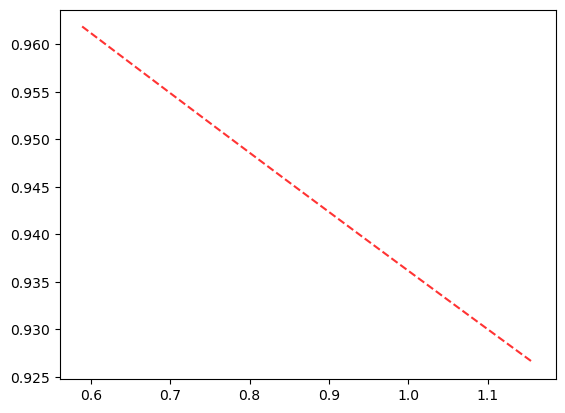

In [9]:
plt.plot(xtest,np.exp(-Ac_M(xtest,alpha_h2o,x)),'r--' , label = r'$\alpha_{H2O}$ = 2.8', alpha = 0.8)